In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")

Libraries loaded.


In [2]:
# LET'S DISSECT THIS

In [3]:
FILE_PATH = 'long_term_jena_10min.csv'  

df = pd.read_csv(FILE_PATH, parse_dates=['datetime']) #I make sure the datetime is a proper Timestamp not TEXT
df = df.set_index('datetime').sort_index() #Making the datetime column as the index helps us to TimeSeries analysis

# Drop the 151 duplicate timestamps (keep first occurrence)
df = df[~df.index.duplicated(keep='first')] #here i try to mark duplicates and then flip and keep the non-duplicates.

print(f"Loaded {len(df):,} rows")
print(f"Time range: {df.index.min()}  →  {df.index.max()}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst rows: SNIPPET OF THE DATA")
df.head()

Loaded 420,630 rows
Time range: 2017-01-01 00:10:00  →  2024-12-31 23:50:00
Columns: ['wind_speed_mps', 'wind_direction_deg', 'temperature_degC']

First rows: SNIPPET OF THE DATA


,wind_speed_mps,wind_direction_deg,temperature_degC
datetime,,,
2017-01-01 00:10:00,0.78,184.0,-4.91
2017-01-01 00:20:00,1.52,202.6,-5.05
2017-01-01 00:30:00,0.98,227.4,-4.98
2017-01-01 00:40:00,1.16,212.5,-4.88
2017-01-01 00:50:00,1.50,222.1,-5.17


In [4]:
year_a = 2020
year_b = 2023

speeds_a = df.loc[f'{year_a}', 'wind_speed_mps'].dropna() # we want our specific column.
speeds_b = df.loc[f'{year_b}', 'wind_speed_mps'].dropna() #using the f-string we convert to string because .loc returns a date range.
# we keep the windspeed because direction and temp are irrelevant for fitting a Weibull.
# we make sure to drop missing values unless the fit would fail.

print(f"{year_a}: {len(speeds_a):,} samples, mean = {speeds_a.mean():.2f} m/s")
print(f"{year_b}: {len(speeds_b):,} samples, mean = {speeds_b.mean():.2f} m/s")

2020: 52,694 samples, mean = 2.19 m/s
2023: 52,557 samples, mean = 2.35 m/s


The slight reduction of the expected samples for these two period is due that 2020 is missing 10 readings (100 mins) and 2023 is missing 3 readings (30 mins).

2023 was windier than 2020 by about 0.16 m/s — roughly 7% higher mean wind.

And why is the mean wind speed for both period far below the typical European onshore wind-farm? Remember this is a 10m height, inland, low-wind site (MEASUREMENT STATION).

Meanwhile, let's imagine where the 7% difference shows up when we fit the Weibull. is it in A, k or even both.

### REPORT 

- 2020 is missing 10 readings (~100 minutes total across the year)
- 2023 is missing 3 readings (~30 minutes)

The mean wind speed in 2023 (2.35 m/s) exceeded that of 2020 (2.19 m/s) by ~7%, indicating stronger overall flow conditions in 2023. 

The Weibull fit clarifies whether this reflects a shift in typical wind magnitude (A), in wind steadiness (k), or both

### Step 2a- Weibull Fit and Plot

2020:  k = 1.457,  A = 2.426 m/s
2023:  k = 1.529,  A = 2.623 m/s


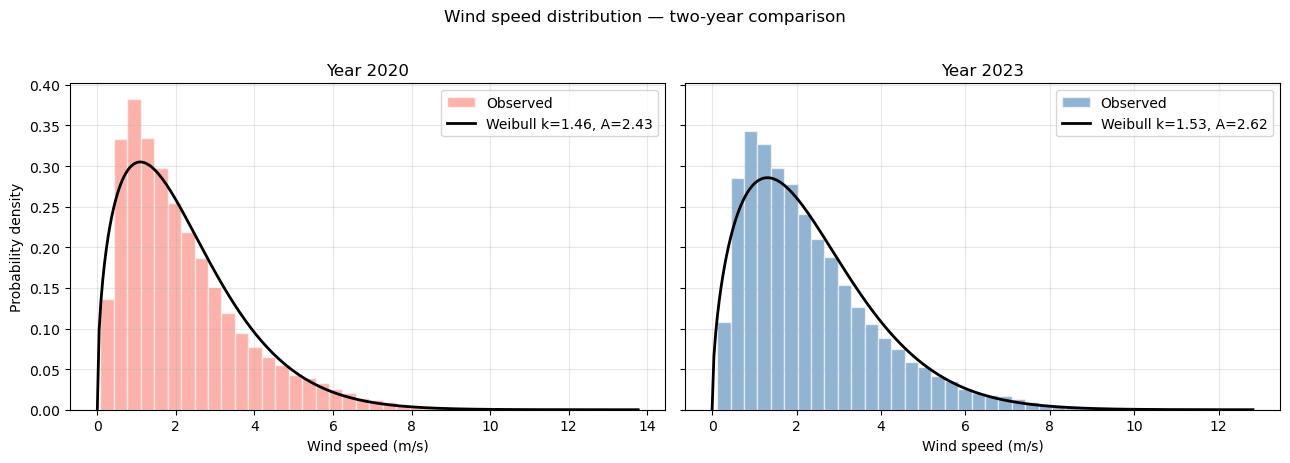

In [5]:
# Fit Weibull to each year, with floc=0 (wind starts at zero!)
k_a, _, A_a = weibull_min.fit(speeds_a, floc=0) #the fit method uses the maximum likelihood estination to match weibull curve to histogram
k_b, _, A_b = weibull_min.fit(speeds_b, floc=0) #we freeze at 0 wind speed using the f prefix so we do not fit it.

print(f"{year_a}:  k = {k_a:.3f},  A = {A_a:.3f} m/s")
print(f"{year_b}:  k = {k_b:.3f},  A = {A_b:.3f} m/s")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, speeds, k, A, year, color in zip(
    axes,
    [speeds_a, speeds_b],
    [k_a, k_b],
    [A_a, A_b],
    [year_a, year_b],
    ['salmon', 'steelblue']
):
    ax.hist(speeds, bins=40, density=True, color=color,
            edgecolor='white', alpha=0.6, label='Observed')
    u_grid = np.linspace(0, speeds.max(), 300)
    ax.plot(u_grid, weibull_min.pdf(u_grid, k, loc=0, scale=A),
            color='black', lw=2, label=f'Weibull k={k:.2f}, A={A:.2f}')
    ax.set_xlabel('Wind speed (m/s)')
    ax.set_title(f'Year {year}')
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Probability density')
plt.suptitle('Wind speed distribution — two-year comparison', y=1.02)
plt.tight_layout()
plt.show()

#### REPORT

- 2020 Weibull fits return k = 1.46, A = 2.43 m/s 
- 2023 Weibull fits return k = 1.53, A = 2.62 m/s

- 8% increase in A indicates 2023 had stronger typical wind speeds, consistent with the 7% increase in raw mean wind speed observed previously.
- slight increase in k (5%) suggests marginally steadier conditions in 2023, though the difference is small enough to fall within typical year-to-year climate variability.
  
- Both years exhibit k well below 2, characteristic of a strongly skewed wind distribution in which calm and near-calm conditions dominate. This is consistent with a sheltered inland site at 10 m height (BGC Jena).

#### Note on observed fit quality
- The fitted curves underestimate the histogram peak near 1 m/s while overestimating wind speeds between 2 and 4 m/s.
- This indicates that a single Weibull distribution is a slightly imperfect model for this site.

Summary: This deviation is physically meaningful: it suggests the wind regime contains more pronounced calm periods than a pure synoptic-driven Weibull would predict, possibly reflecting the influence of surface roughness and local sheltering effects. 

### Step 2b- Wind Rose
Objective: Plotting Wind rose. Identifying prevailing wind directions and dominant sectors.
Insight: WR is a meterologist's version of a histogram, but for circular data.

WR shows two things;
- Direction: SW blows from south, pointing northward (angle around the circle)
- Frequency (length of each petal)
- Often also speed (color-coded)

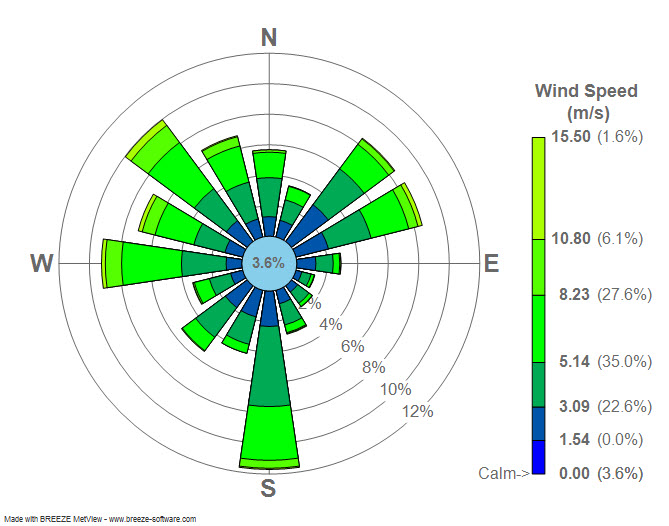

#### Important point to note - "WE DO NOT FIT A GAUSSIAN TO WIND DIRECTION". why? why?
Simply because Wind direction is CIRCULAR. 359° and 1° are neighbors, not opposites. The mean of 359° and 1° should be 0° (or 360°), not 180°. A normal Gaussian-style histogram completely fails for this. 

Now we build the beautiful wind rose :)

Wind rose for 2023: 52,557 valid samples


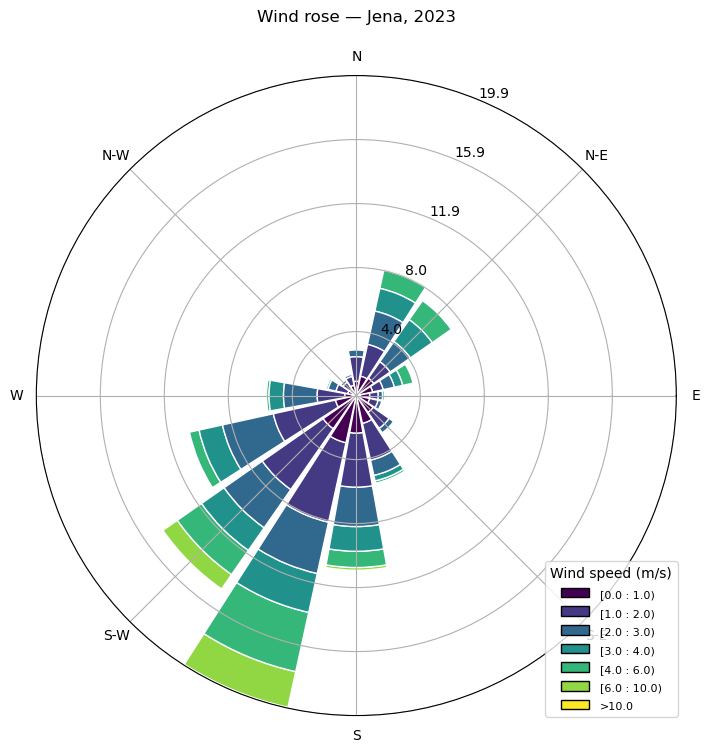

In [6]:
from windrose import WindroseAxes

# We'll do one full year. Pick whichever you want — let's start with 2023.
year_for_rose = 2023

speed_year = df.loc[f'{year_for_rose}', 'wind_speed_mps']
direction_year = df.loc[f'{year_for_rose}', 'wind_direction_deg']

# Drop any rows where either is NaN
valid = speed_year.notna() & direction_year.notna()
speed_year = speed_year[valid]
direction_year = direction_year[valid]

print(f"Wind rose for {year_for_rose}: {len(speed_year):,} valid samples")

# Create the polar axes object and draw the rose
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(direction_year, speed_year,
       bins=[0, 1, 2, 3, 4, 6, 10],  # wind-speed bands in m/s
       normed=True,                    # show percentages, not raw counts
       opening=0.9,
       edgecolor='white')
ax.set_legend(title='Wind speed (m/s)', loc='lower right')
ax.set_title(f'Wind rose — Jena, {year_for_rose}', pad=20)
plt.show()

 #### Interpretation of Wind Rose in plain terms

 - The wind at Jena comes majorly from south-southwest. It reaches 19.9% ring.
 - The dominant petal is between S and SW. We expect this because inland Germany is the **Atlantic westerly regime**. Central Germany sits in the westerly belt (lecture slide 9 - the global circulation cells, "Westerlies")
 - At east-northeast, the petal is smaller and reahces around 8%. This is a **secondary wind regime**. It is likely associated with **high-pressure (anticyclonic) situations**. This situation happens when winds over Germany swing round to come from the east. Several German inland sites show this bimodal SW/E patterns.
 - The purple-dominated part of the rose confirms the low-wind, calm-dominated character of the site already identified from the Weibull fit (low k).


**Remember: where the wind comes from often" is NOT "where the energy comes from." Energy depends on wind speed cubed. A direction that blows at 6 m/s a little can out-produce a direction that blows at 3 m/s a lot.**

### Step 2c- Energy Proxy

**Objective**: Here we want to know contribution of each direction sector to the total wind energy (in %). 

The wind speed enters as U cubed. That cube changes everything:
- Double the wind speed → 8× the power (2³ = 8)
- Triple the wind speed → 27× the power (3³ = 27)

**So a direction that brings moderately strong wind, even occasionally, can dominate the energy budget while a direction that brings frequent but weak wind contributes almost nothing.**

Example; Suppose direction A blows at 2 m/s for 1000 hours, and direction B blows at 6 m/s for only 200 hours.

- By frequency, A wins 5-to-1 (1000 vs 200 hours).
- By energy: A contributes 1000 × 2³ = 8,000 units; B contributes 200 × 6³ = 43,200 units. B wins by more than 5-to-1.

**Same data, opposite conclusion**

Note this is a proxy — it ignores air density, the rotor area, the power coefficient, cut-in/cut-out limits. It captures only the part that depends on wind: the u³.

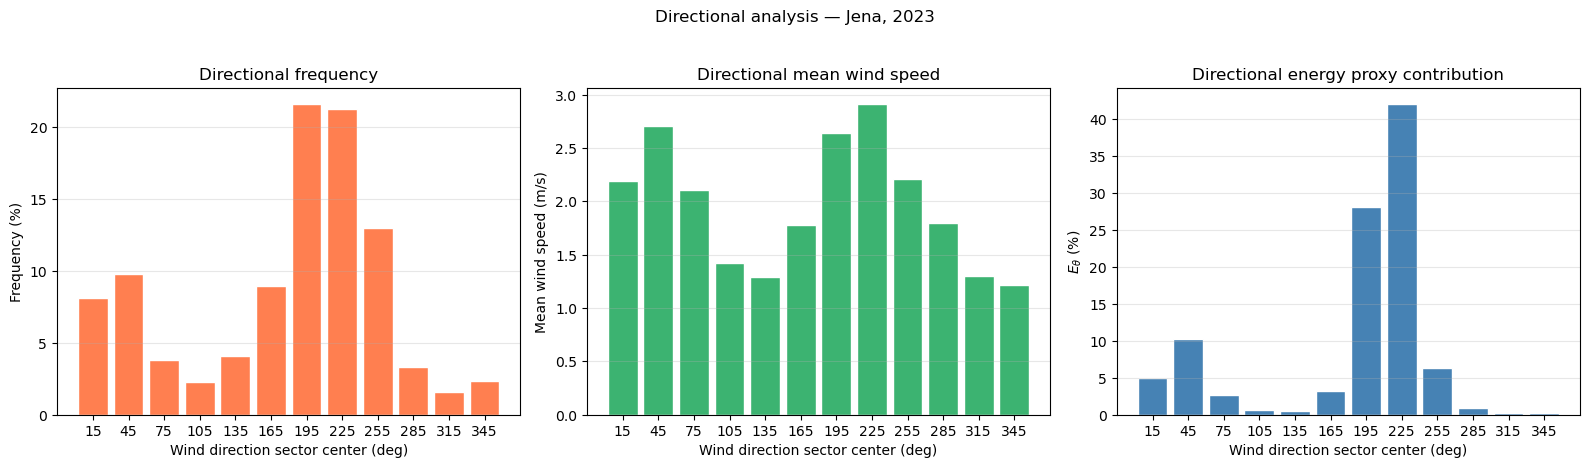

  Sector    Freq%    MeanU   Energy%
    15       8.1    2.19      5.0
    45       9.8    2.71     10.2
    75       3.8    2.11      2.6
   105       2.2    1.42      0.6
   135       4.1    1.29      0.5
   165       9.0    1.78      3.2
   195      21.6    2.64     28.0
   225      21.2    2.91     42.1
   255      12.9    2.21      6.4
   285       3.3    1.80      0.9
   315       1.6    1.30      0.2
   345       2.3    1.22      0.2


In [7]:
import numpy as np

# --- Use one full year ---
year_for_energy = 2023
sp  = df.loc[f'{year_for_energy}', 'wind_speed_mps']
dr  = df.loc[f'{year_for_energy}', 'wind_direction_deg']

# Keep only rows where BOTH speed and direction are valid
ok = sp.notna() & dr.notna()
sp = sp[ok].values      # .values -> plain numpy array
dr = dr[ok].values

# --- Bin directions into 12 sectors of 30 degrees ---
sector_edges   = np.arange(0, 361, 30)            # 0,30,...,360
sector_centers = sector_edges[:-1] + 15           # 15,45,...,345
# For each reading, which sector (0-11) does it fall in?
sector_index = np.digitize(dr, sector_edges) - 1
sector_index = np.clip(sector_index, 0, 11)       # guard against dir == 360

# --- Total energy proxy over the whole year ---
total_u3 = np.sum(sp**3)

# --- Loop over the 12 sectors and compute three quantities ---
frequency   = np.zeros(12)
mean_speed  = np.zeros(12)
energy_pct  = np.zeros(12)

for s in range(12):
    in_sector = (sector_index == s)          # True/False mask for this sector
    n_in      = in_sector.sum()              # how many readings in this sector

    frequency[s]  = n_in / len(sp) * 100     # % of the year from this sector
    if n_in > 0:
        mean_speed[s] = sp[in_sector].mean()             # mean wind in sector
        energy_pct[s] = np.sum(sp[in_sector]**3) / total_u3 * 100

# --- Plot all three side by side ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(sector_centers, frequency, width=25, color='coral', edgecolor='white')
axes[0].set_title('Directional frequency')
axes[0].set_ylabel('Frequency (%)')

axes[1].bar(sector_centers, mean_speed, width=25, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Directional mean wind speed')
axes[1].set_ylabel('Mean wind speed (m/s)')

axes[2].bar(sector_centers, energy_pct, width=25, color='steelblue', edgecolor='white')
axes[2].set_title('Directional energy proxy contribution')
axes[2].set_ylabel(r'$E_\theta$ (%)')

for ax in axes:
    ax.set_xlabel('Wind direction sector center (deg)')
    ax.set_xticks(sector_centers)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle(f'Directional analysis — Jena, {year_for_energy}', y=1.03)
plt.tight_layout()
plt.show()

# --- Print a summary table ---
print(f"{'Sector':>8}  {'Freq%':>7}  {'MeanU':>7}  {'Energy%':>8}")
for s in range(12):
    print(f"{sector_centers[s]:6.0f}    {frequency[s]:6.1f}  {mean_speed[s]:6.2f}  {energy_pct[s]:7.1f}")

### Interpretation of Energy Proxy

- The SW at 225° blows 21% of the time but delivers 42% of the energy.
- The single **most frequent** sector is **195°**(SSW) at 21.6%, marginally ahead of 225° (SW) at 21.2%. But the **single most energetic** sector is **225°**, by a wide margin (42.1% vs 28.0%).
- The most frequent direction is not the most energetic direction.


#### Interesting Insights
- 195° + 225° = 70% of energy. This site is extremely directional
- **My favourite insight** actually; Look at 135°, 345° even 315°. These appear 4.1%, 2.3% and 1.6% of the time respectively. On the contrast on the energy mix, 0.5%, 0.2%, 0.2%. **What does this teach us** - **"Cube a small number and it becomes a tiny number."**
- **A sector's energy is governed by how strong its wind is, far more than how often it blows. (LOOK AT 225° and 255°)**

Now let us move over to the next! :)

 ### Step 3- DETRENDING or DECOMPOSITION
I sketched how i visualize the three layers in a wind speed below. 

Objective: Wind measurement is a messy scribble. We need to split into these three clean pieces and study each.

Each layer lives at a different scale and matters for a different reason.

- Trend → wind resource and multi-day forecasting (synoptic).
- Seasonal → predictable daily rhythm, useful for scheduling.
- Residual → the unpredictable part. For an onshore site, the lecture (slide 29) tells you the residual usually dominates — more than twice the size of the daily cycle.

 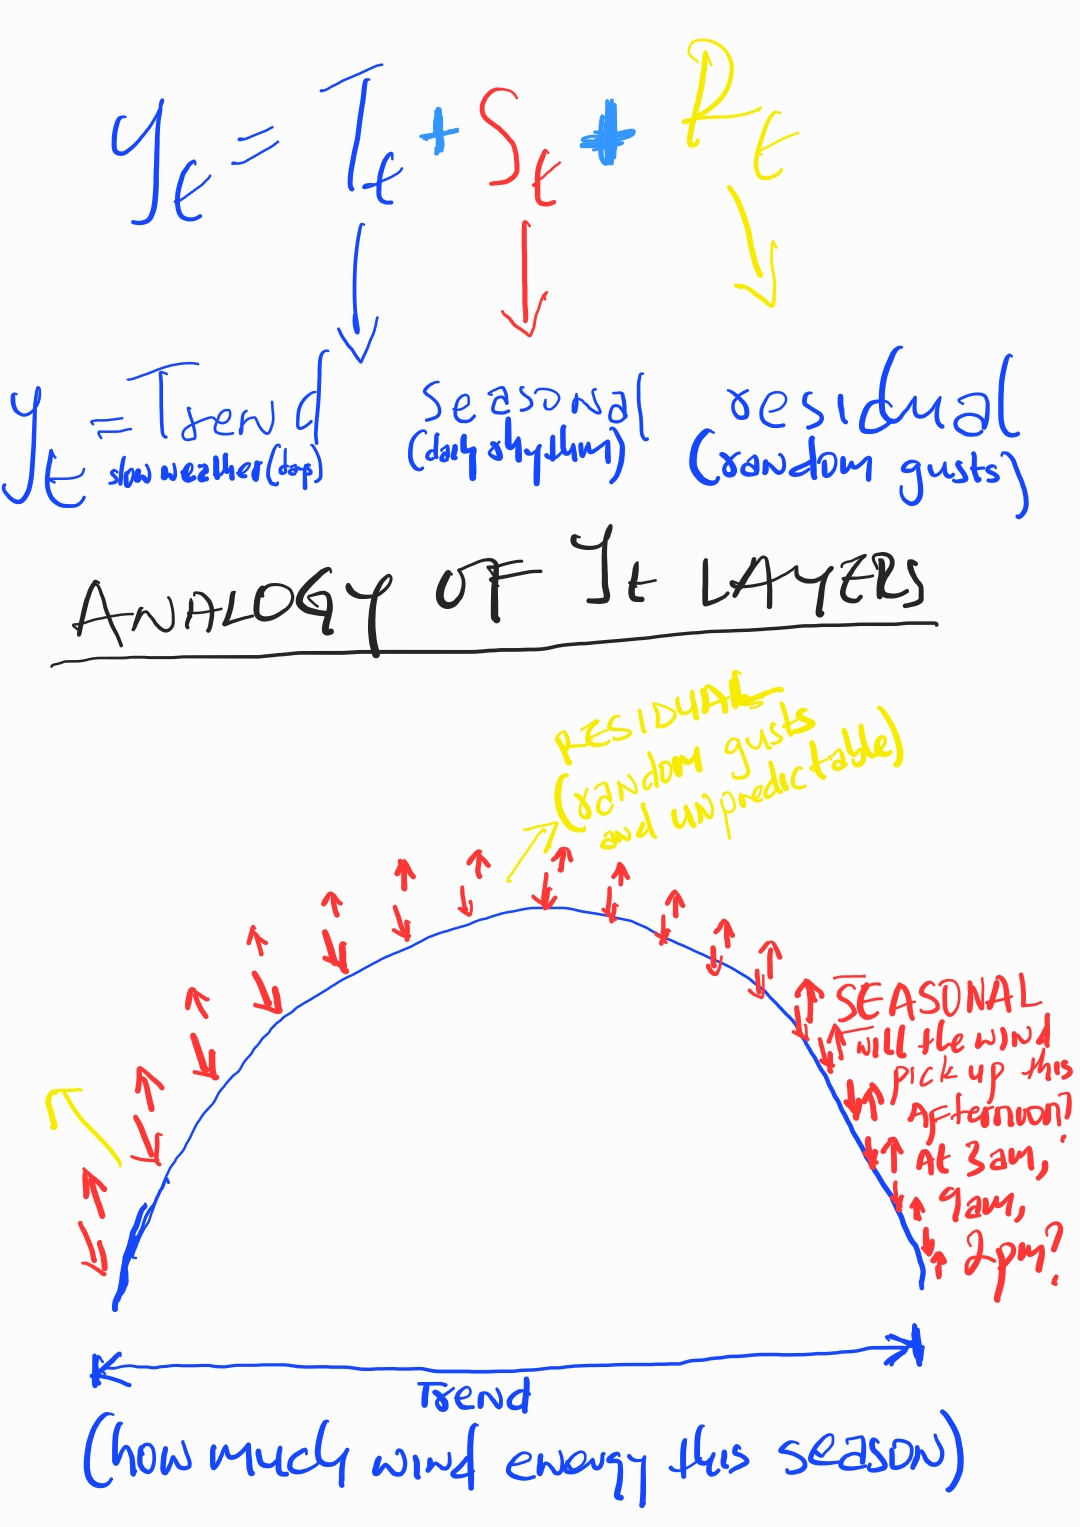

Want to remove the daily cycle? Blur with a one-day window. Why? Because exactly 1 day is enough to erase a one full daily cycle but not wide to eat a multi-day weather.

#### How to think and execute DECOMPOSITION
The fundamental idea is "moving average" either blurring. Wind speed is like a bumpy line and blurring smoothens this out. (Do quick search on how moving averages work).

To decompose, think of these 3 layers like that in an onion.

step 1: what rhythm are you looking for? 
- We are looking for what the wind repeats every 24 hours. So our timescale is **one day**.
- We measure wind every 10 minutes, therefore **one day is 144 measurements or points**.

step 2: Cutting the outer onion layer (TREND). 
- We blur the original either bumpy wind signal using a window of one day.
- why not one hour or one week? Because 1hr erases the random gust but not the daily rhythm. Then for one week, it erases both the daily rhythm and random gust but could even start erasing some part of slower weather (TREND) which we want to keep.
- So, exactly 1 day erases one full daily cycle but not a multi-day weather.
- **So after a one-day-wide blur, what's left is only the slow weather.**

step 3: We get the DETRENDED SIGNAL = the wind with the slow weather removed.
- Detrended = original bumpy signal - Trend (smooth line in step 2)
- In other words, **a detrended signal has daily rhythm and the random gusts are left**.

step 4: Pull out Daily rhythm
- We need to remember that rhythm repeats every daily but these has some random gusts. Averaging across many days makes the random gusts cancel out.
- Whatever survives from averaging above is the part that stays same daily - RHYTHM (we want this, actually)
- Averaging destroys what's random and preserves what's consistent.

Raw segment: 12,960 rows
Clean segment: 12,960 rows on a regular grid


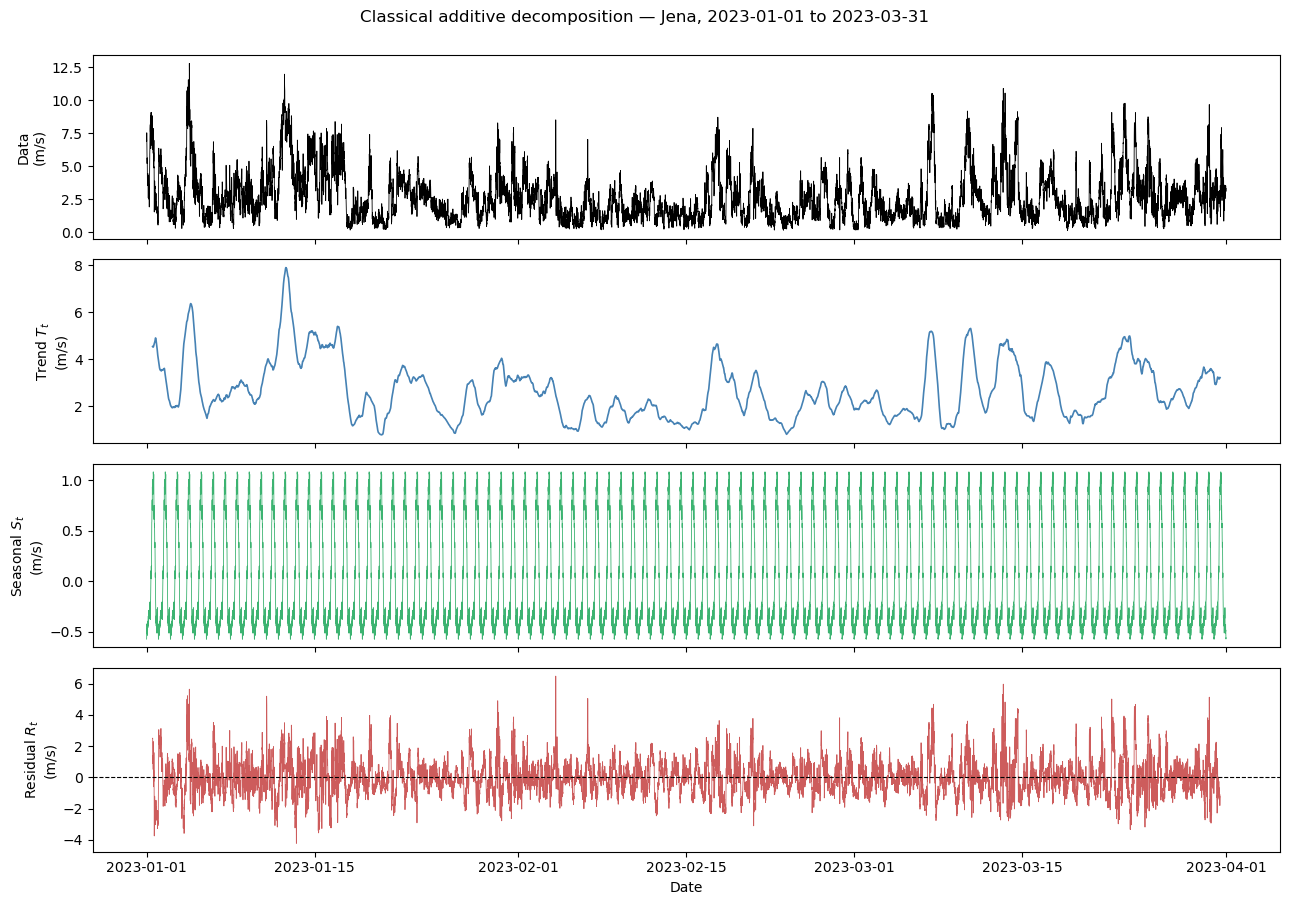

In [9]:
#the function seasonal_decompose handles the 5 step peeling.
from statsmodels.tsa.seasonal import seasonal_decompose

# Jan 1st 2023 - March 31st 2023 so a 3 month period
start = '2023-01-01'
end   = '2023-03-31'

# i need every timestamp within this 3 month period and the wind_speed_mps
segment = df.loc[start:end, 'wind_speed_mps']
print(f"Raw segment: {len(segment):,} rows") # to verify row count either 90 days * 144

#################### Time grid #####################
# using the function seasonal_decompose, we need every 10 mins slot present with no duplicates
segment = segment.resample('10min').mean() #10 mins time grid, average duplicate timestamps into a single value
segment = segment.interpolate(limit=6)
segment = segment.dropna()
print(f"Clean segment: {len(segment):,} rows on a regular grid")

################### Decompose: daily cycle = 144 ten-minute steps ##############
samples_per_day = 6 * 24      # 144 (6 per hour x 24 hours)
result = seasonal_decompose(segment, model='additive', period=samples_per_day)

# --- 4. Plot the four panels ---
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

axes[0].plot(result.observed, color='black', lw=0.6)
axes[0].set_ylabel('Data\n(m/s)')

axes[1].plot(result.trend, color='steelblue', lw=1.2)
axes[1].set_ylabel('Trend $T_t$\n(m/s)')

axes[2].plot(result.seasonal, color='mediumseagreen', lw=0.6)
axes[2].set_ylabel('Seasonal $S_t$\n(m/s)')

axes[3].plot(result.resid, color='indianred', lw=0.6)
axes[3].set_ylabel('Residual $R_t$\n(m/s)')
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_xlabel('Date')

plt.suptitle(f'Classical additive decomposition — Jena, {start} to {end}', y=1.0)
plt.tight_layout()
plt.show()

At Jena, multi-day weather systems are the biggest influence on wind. Random gusts come second. The predictable daily rhythm is the smallest of the three.

##### With the code below, we briefly want to know the Standard deviation of each component. 

In [10]:
import numpy as np

# Standard deviations of each component (ignore NaNs at the edges of the trend)
sigma_T = np.nanstd(result.trend)
sigma_S = np.nanstd(result.seasonal)
sigma_R = np.nanstd(result.resid)

print(f"Trend     (T):   sigma = {sigma_T:.3f} m/s")
print(f"Seasonal  (S):   sigma = {sigma_S:.3f} m/s")
print(f"Residual  (R):   sigma = {sigma_R:.3f} m/s")
print()
print(f"Residual / Seasonal ratio: {sigma_R/sigma_S:.2f}")
print(f"Residual / Trend    ratio: {sigma_R/sigma_T:.2f}")

Trend     (T):   sigma = 1.216 m/s
Seasonal  (S):   sigma = 0.526 m/s
Residual  (R):   sigma = 1.137 m/s

Residual / Seasonal ratio: 2.16
Residual / Trend    ratio: 0.94


The classical additive decomposition of Jan–Mar 2023 wind speed at Jena separates the signal into trend
Tt​, seasonal StS_t
St​, and residual RtR_t
Rt​ components. 

The *trend panel* reveals approximately **8–10 distinct synoptic weather episodes** during the three-month period, with trend ranging from ~1 m/s during calm anticyclonic spells (e.g. mid-January) to ~8 m/s during the early-January windy episode. 

The *seasonal component* shows a daily cycle of approximately 1 m/s peak-to-trough. The standard deviations quantify the hierarchy: σT\sigma_T
σT​ = 1.22 m/s (synoptic weather), σR\sigma_R
σR​ = 1.14 m/s (random fluctuations), σS\sigma_S
σS​ = 0.53 m/s (daily rhythm). 

The residual-to-seasonal ratio is 2.16, in close agreement with the lecture finding that random variability at onshore sites typically exceeds the daily cycle by a factor of approximately two Trend and residual contribute roughly equal variance, while the daily cycle accounts for less than half of either. 

This indicates that at this site, day-to-day wind variability is governed primarily by synoptic-scale weather and microscale random fluctuations rather than by the diurnal cycle.

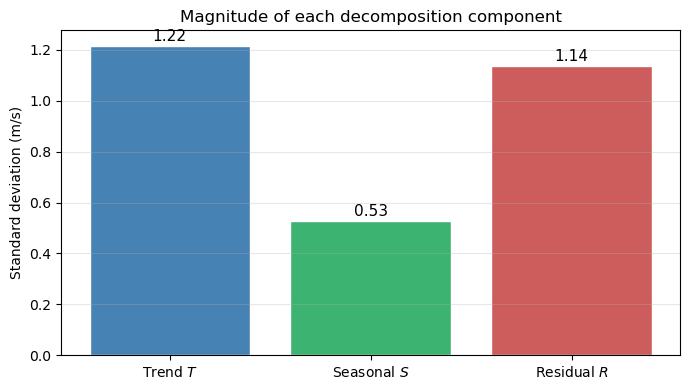

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Trend $T$', 'Seasonal $S$', 'Residual $R$'],
       [sigma_T, sigma_S, sigma_R],
       color=['steelblue', 'mediumseagreen', 'indianred'],
       edgecolor='white')
ax.set_ylabel('Standard deviation (m/s)')
ax.set_title('Magnitude of each decomposition component')
ax.grid(alpha=0.3, axis='y')

# Print the values on top of the bars
for i, val in enumerate([sigma_T, sigma_S, sigma_R]):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Exercise 4
Seasonal Diurnal Cycle and Variability


Total rows: 420,629
season
Spring    105972
Summer    105902
Autumn    104789
Winter    103966
Name: count, dtype: int64

Mean wind by hour, by season (m/s):
season  Autumn  Spring  Summer  Winter
hour                                  
0         1.58    1.49    1.25    2.20
1         1.57    1.46    1.21    2.17
2         1.57    1.42    1.17    2.18
3         1.61    1.43    1.14    2.15
4         1.60    1.44    1.13    2.12
5         1.60    1.48    1.15    2.15
6         1.62    1.59    1.29    2.14
7         1.68    1.85    1.58    2.16
8         1.85    2.17    1.90    2.23
9         2.11    2.60    2.25    2.33
10        2.43    2.99    2.54    2.58
11        2.69    3.23    2.73    2.84
12        2.81    3.36    2.83    3.00
13        2.86    3.41    2.88    3.07
14        2.78    3.42    2.89    3.04
15        2.61    3.35    2.81    2.84
16        2.32    3.19    2.66    2.68
17        2.08    2.93    2.46    2.52
18        1.93    2.49    2.18    2.40
19        1.84    2.11 

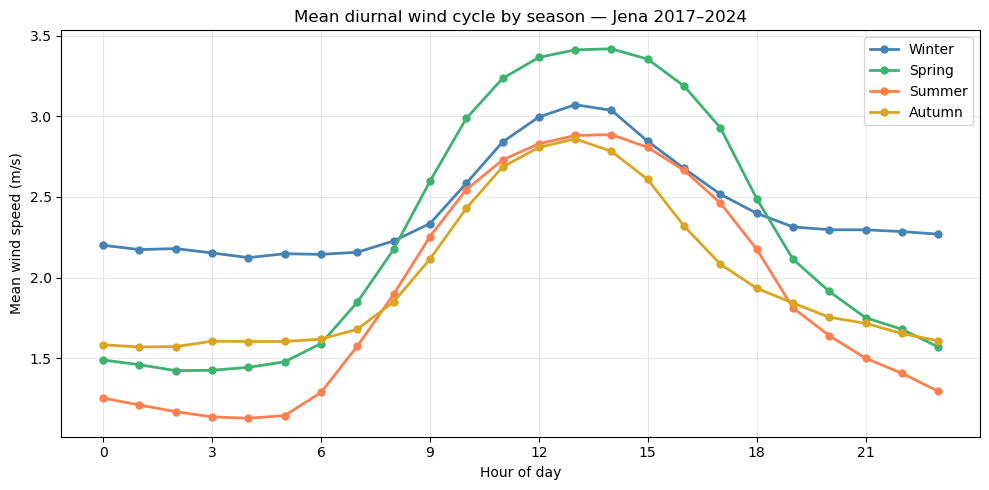

In [12]:
import numpy as np

# Use the WHOLE dataset
wind = df['wind_speed_mps'].dropna()

# --- Tag each timestamp with its season and hour-of-day ---
def month_to_season(m):
    if m in (12, 1, 2):  return 'Winter'
    if m in (3, 4, 5):   return 'Spring'
    if m in (6, 7, 8):   return 'Summer'
    return 'Autumn'

# Build a working DataFrame
w = pd.DataFrame({'u': wind})
w['hour']   = w.index.hour
w['season'] = w.index.month.map(month_to_season)

print(f"Total rows: {len(w):,}")
print(w['season'].value_counts())

# --- For each season, average wind by hour ---
diurnal = w.groupby(['season', 'hour'])['u'].mean().unstack('season')
# 'diurnal' is now a 24-row table: rows are hours 0-23, columns are seasons

print("\nMean wind by hour, by season (m/s):")
print(diurnal.round(2))

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Winter': 'steelblue', 'Spring': 'mediumseagreen',
          'Summer': 'coral',     'Autumn': 'goldenrod'}

for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    ax.plot(diurnal.index, diurnal[season], 'o-',
            color=colors[season], label=season, lw=2, markersize=5)

ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean wind speed (m/s)')
ax.set_title('Mean diurnal wind cycle by season — Jena 2017–2024')
ax.set_xticks(range(0, 24, 3))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Three observations
- **Spring has the strongest afternoon wind, not summer**. Spring peaks at ~3.4 m/s, summer at only ~2.9. Why? Because spring combines strong solar heating with still-active synoptic systems crossing Europe. Summer has even stronger heating but weaker synoptic forcing so the jet stream retreats north and weather systems are less active over Germany. So spring is your "best of both worlds" season for afternoon wind.
  
- **Summer has the deepest night-time minimum.**
Summer drops to ~1.2 m/s around 04:00. That's because clear summer nights produce the strongest possible nocturnal decoupling — the ground cools rapidly, a thin layer of cold air sits near the surface, and any wind above completely decouples from the sensor at 10 m. The sensor effectively reads "trapped, calm air" at night.

- **Winter is essentially flat — and ABOVE the others at night.**
This is the most physically interesting part. Winter night wind (~2.1 m/s) is higher than spring/summer/autumn night wind (~1.2–1.6 m/s) — even though winter daytime wind is lower than spring's. The night/day asymmetry collapses.


Since we know that air above moves faster than those close to the ground, how much of that fast uipper-air gets mixed down to 10m sensor?

Every season has a stron afternoon peak except the Winter because of the vertical convextive mixing at the boundary layer.

At clear-sky night the ground cools raidly, cold air is dense and senor at 10m sits inside this region (near-calm). This causes the surface wind to drop to its minimum. 

#### Report
The mean diurnal cycle of wind speed at Jena was computed for all four meteorological seasons across 2017–2024. Three of the four seasons — spring, summer, and autumn — exhibit a pronounced daily cycle with a night-time minimum around 03–05 h and a sharp afternoon peak between 13–14 h. 

Spring shows the largest peak-to-trough swing (~2.0 m/s), with the highest afternoon wind speed of all seasons (~3.4 m/s); 

Summer shows the deepest night-time minimum (~1.2 m/s). 

Winter is markedly different: the daily cycle is essentially flat, with only a modest ~1 m/s swing, and winter wind exceeds all other seasons at night. This contrast reflects the seasonal cycle of atmospheric stability and forcing. 

In spring/summer/autumn, daytime solar heating drives convective mixing of the boundary layer, transporting momentum from aloft down to the surface and producing the afternoon wind peak; 

At night, clear-sky radiative cooling produces a stable surface layer that decouples the sensor from the faster wind above, yielding the deep nocturnal minimum. 

In winter, weak solar elevation suppresses both effects: there is too little daytime heating to drive strong convection, and too little day-night radiative contrast to produce sustained nocturnal decoupling. Winter wind is therefore primarily driven by synoptic-scale Atlantic depressions, which produce sustained, mixed, near-uniform wind regardless of time of day.

### Burstiness by season

Burstiness - *How much of the random part is spread (spikes) vs how much is concentrated mean offset*

Let's say we have two days;
DAY ONE - small steady loads
DAY TWO - long quiet, then a sudden shock load (can break blades)

*Burstiness* wants to capture if "wiggling is smooth or spiky"

We cannot use the previous function seasonal_decompose on 8 years cleanly so we need a simple short moving-average detrend. 

Coefficient of variation of residuals, by (hour, season):
season  Autumn  Spring  Summer  Winter
hour                                  
0        1.368   1.354   1.384   1.383
1        1.346   1.357   1.366   1.382
2        1.349   1.389   1.370   1.420
3        1.348   1.384   1.353   1.388
4        1.351   1.401   1.369   1.400


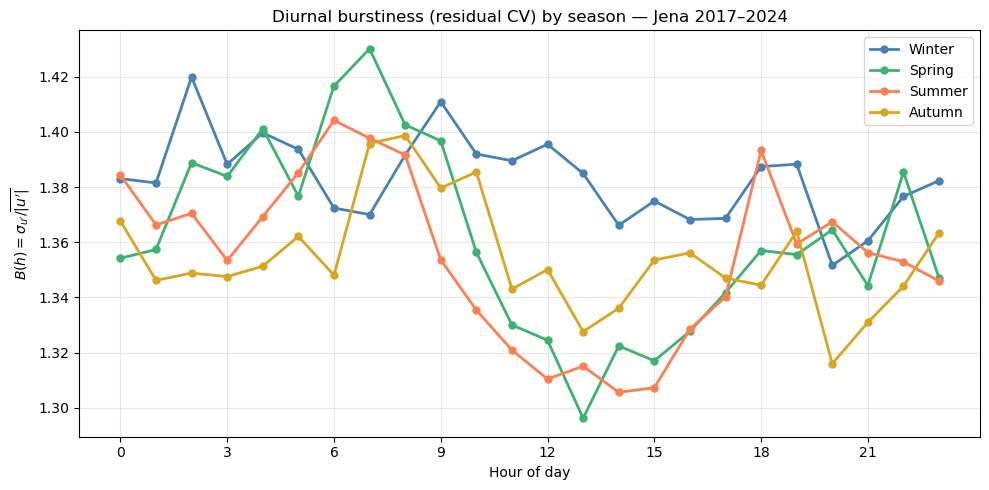

In [15]:
# ---------- Cell 8b: Coefficient of variation of residuals, by season and hour ----------

# Re-use uprime and the working DataFrame b from before (re-run if needed):
u    = df['wind_speed_mps']
ubar = u.rolling(window=6, center=True, min_periods=3).mean()
uprime = (u - ubar).dropna()

b = pd.DataFrame({'uprime': uprime})
b['hour']   = b.index.hour
b['season'] = b.index.month.map(month_to_season)

# The KEY change: use mean of |u'|, not |mean of u'|
b['abs_uprime'] = b['uprime'].abs()

grouped = b.groupby(['season', 'hour'])

sigma_up   = grouped['uprime'].std()           # spread
mean_abs_up = grouped['abs_uprime'].mean()     # typical magnitude (always > 0)

# B is now stable: sigma divided by a positive, non-tiny number
B = (sigma_up / mean_abs_up).unstack('season')

print("Coefficient of variation of residuals, by (hour, season):")
print(B.round(3).head())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for season in ['Winter', 'Spring', 'Summer', 'Autumn']:
    ax.plot(B.index, B[season], 'o-',
            color=colors[season], label=season, lw=2, markersize=5)

ax.set_xlabel('Hour of day')
ax.set_ylabel(r"$B(h) = \sigma_{u'}/\overline{|u'|}$")
ax.set_title('Diurnal burstiness (residual CV) by season — Jena 2017–2024')
ax.set_xticks(range(0, 24, 3))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 #### OBSERVATION ON DIURNAL BURSTINESS 
  - For a *pure Gaussian nosie* the ratio is approximately *1.253*. Anything higher means the fluctuations are spikier than Gaussian — heavy-tailed, intermittent.
  - You can observe that we have here values from 1.30 (low end, smooth fluctuation) to ~1.43 (high end, burstier fluctuations).
  - It can also be seen from this that our whole plot sits above *a pure Gaussian noise* either 1.253, meaning *wind fluctuations at Jena* are always somewhat *heavy-tailed - NEVER GAUSSIAN.*

#### OBSERVED PATTERNS IN GRAPH
###### Pattern 1
- **SUMMER** has the strongest day-night contrast.
- Early morning (05–07h): peaks at ~1.40 — bursty
- Midday/afternoon (11–16h): drops to ~1.31 — smooth
- Evening climb (17–20h): rises back toward ~1.39
- Daily swing ≈ *0.09 — the largest of all seasons*

###### Pattern 2
- **WINTER** is the burstiest and the flattest.
- Sits highest overall, often around 1.38–1.42

*Highlight*
- A turbine in summer afternoon sees: ~3 m/s of smooth, well-developed turbulence — manageable loads, predictable behaviour.
- A turbine in winter afternoon sees: ~3 m/s of spikier, intermittent turbulence — same average wind, but with more violent fluctuation events embedded.

Therefore "TI does NOT equal single-scale burstiness/spikiness." Turbulence intensity (TI = σ/mean) at these two seasons might be similar though same standard deviation, same mean but **burstiness** tells you one is dangerous and one is benign.